Ojective:
To build a convolutinal Auto encoder(CAE) that compress facial images into a lower dimensional latend represents and reconstructs them wit  minimal loss of information

purpose:
A convolutional autoencoder is an unsupervised deep learning model used for
Image compresion image recognition feature extraction dimensinality Reduction
The encoder learns a compressed representation (latent space) while the decoder reconstructs the original image from this compressed representation

In [1]:
  #libraries
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model

In [2]:
!pip install -q kaggle

In [3]:
from google.colab import files
files.upload()

{}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [5]:
!kaggle datasets download -d jessicali9530/celeba-dataset

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
100% 1.33G/1.33G [01:04<00:00, 22.3MB/s]



In [6]:
!unzip -q celeba-dataset.zip

In [7]:
import os
import shutil
source_folder= os.path.join("img_align_celeba","img_align_celeba")
destination_folder= "celeba_small/faces"
os.makedirs(destination_folder,exist_ok=True)
images=sorted(os.listdir(source_folder))[:5000]
for image in images:
  shutil.copy(
      os.path.join(source_folder,image),
      destination_folder)

print("Copied",len(images),"images")

Copied 5000 images


In [8]:
IMAGE_SIZE=(64,64)
BATCH_SIZE=32

In [9]:
datagen=ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
    )

In [10]:
train_generator=datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="training"
)

Found 4000 images belonging to 1 classes.


In [11]:
validation_generator=datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="validation"
)

Found 1000 images belonging to 1 classes.


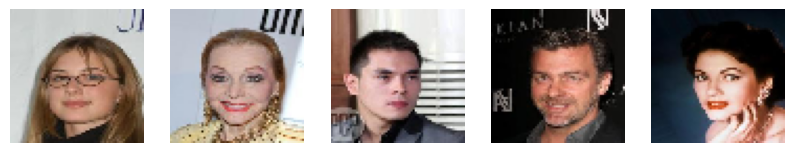

In [12]:
images,_ = next(train_generator)
plt.figure(figsize=(10,5))
for i in range(5):
  plt.subplot(1,5,i+1)
  plt.imshow(images[i])
  plt.axis("off")
plt.show()

In [13]:
input_img=Input(shape=(64,64,3))
x=Conv2D(
    32,
    (3,3),
    activation="relu",
    padding="same"
    )(input_img)
x=MaxPooling2D((2,2),padding="same")(x)

In [14]:
#Encoder
input_img=Input(shape=(64,64,3))
x=Conv2D(
    32,
     (3,3),
    activation="relu",
    padding="same"
    )(input_img)
x=Conv2D(
    32,
    (2,2),
         padding="same"
         )(x)
x= Conv2D(
    64,
    (3,3),
    activation="relu",
    padding="same"
)(x)
encoded=MaxPooling2D(
    (2,2),
    padding="same"
    )(x)

In [15]:
# Decoder part
x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = Conv2D(32, (2, 2), activation='relu', padding='same')(x)
decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

# Autoencoder model
autoencoder = Model(input_img, decoded)

# Compile the model
autoencoder.compile(optimizer='adam', loss='mse')

history=autoencoder.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - loss: 0.0191 - val_loss: 0.0061
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0046 - val_loss: 0.0035
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.0033 - val_loss: 0.0031
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.0025 - val_loss: 0.0022
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0021 - val_loss: 0.0019
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.0019 - val_loss: 0.0017
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.0017 - val_loss: 0.0015
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0015 - val_loss: 0.0013
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.0013 - val_loss: 0.0014
Epoch 10/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.0013 - val_loss: 0.0018


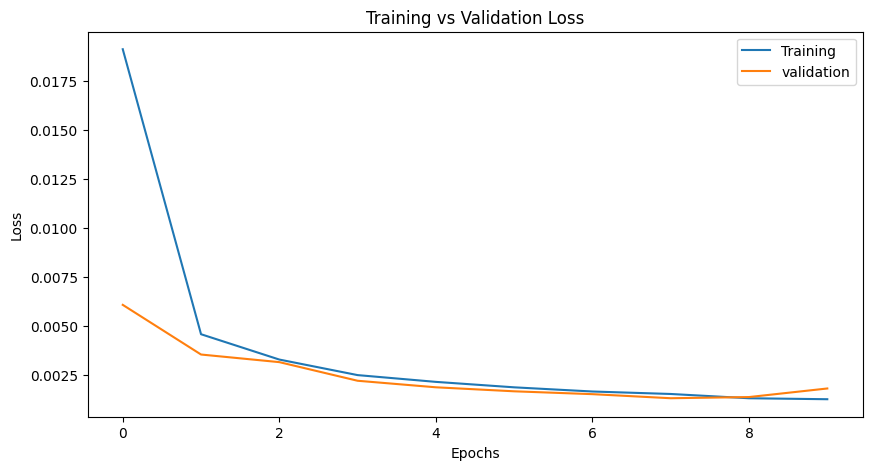

In [16]:
plt.figure(figsize=(10,5))
plt.plot(history.history["loss"],label="Training loss")
plt.plot(history.history["val_loss"],label="Validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend(["Training", "validation"])
plt.show()

In [17]:
loss = autoencoder.evaluate(validation_generator)
print("Validation Loss:", loss)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0018
Validation Loss: 0.0018061657901853323


In [18]:
#reconstruct Images
images, _ = next(validation_generator)
decoded_images = autoencoder.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step


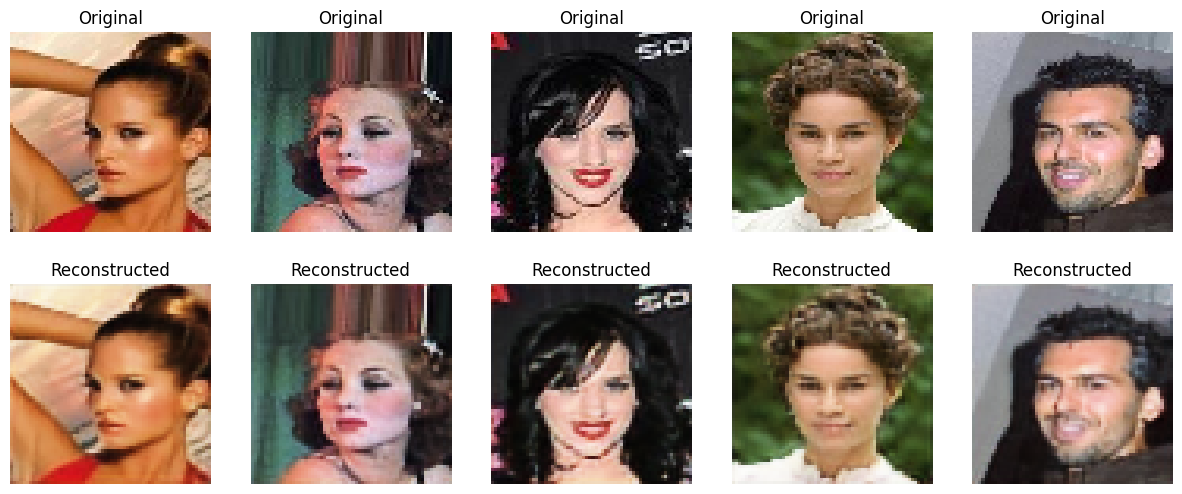

In [19]:
#display Results
n=5
plt.figure(figsize=(15, 6))
for i in range(n):
    plt.subplot(2, n, i + 1)
    plt.imshow(images[i])
    plt.title("Original")
    plt.axis("off")
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_images[i])
    plt.title("Reconstructed")
    plt.axis("off")
plt.show()


In [20]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Recompile with a smaller learning rate
autoencoder.compile(
    optimizer=Adam(learning_rate=5e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

history_tuned = autoencoder.fit(
    train_generator,
    epochs=64,
    callbacks=[early_stop, reduce_lr],
    validation_data=validation_generator,
    verbose=1
)

old_loss = min(history.history['val_loss'])
new_loss = min(history_tuned.history['val_loss'])

print("Validation Loss Before :", old_loss)
print("Validation Loss After  :", new_loss)
print("Improvement : {:.2f}%".format(((old_loss-new_loss)/old_loss)*100))

Epoch 1/64
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.8916 - loss: 0.4726 - val_accuracy: 0.8946 - val_loss: 0.4728 - learning_rate: 5.0000e-05
Epoch 2/64
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.8934 - loss: 0.4723 - val_accuracy: 0.8932 - val_loss: 0.4727 - learning_rate: 5.0000e-05
Epoch 3/64
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.8945 - loss: 0.4723 - val_accuracy: 0.8888 - val_loss: 0.4727 - learning_rate: 5.0000e-05
Epoch 4/64
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.8946 - loss: 0.4722 - val_accuracy: 0.8861 - val_loss: 0.4726 - learning_rate: 5.0000e-05
Epoch 5/64
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.8942 - loss: 0.4722 - val_accuracy: 0.8888 - val_loss: 0.4726 - learning_rate: 5.0000e-05
Epoch 6/64
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.8949 - loss: 0.4721 - val_accuracy: 0.8883 - val_loss: 0.4725 - learning_rate: 5.0000e-05
Epoch 7/64
123/125 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc